In [5]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Explanation

This model attempts to forecast the logarithm of cyanobacteria abundance at different time frames in the future. To do this, I built datasets that are "missing" time chunks before sample_date to simulate the fact that for a true forecast model we wouldn't have access to this data. I will once again use an LSTM model for this. In another file I will have a similar procedure but using a classification task instead of a regressor.

#### Defining functions for model training

In [2]:
#scaling features 
def scale_data(xdata, scaler=None, fit=True):
    n_samples, seq_len, n_features = xdata.shape
    x2d = xdata.reshape(-1, n_features)

    if fit:
        scaler = StandardScaler()
        x_scaled_2d = scaler.fit_transform(x2d)
    else:
        x_scaled_2d = scaler.transform(x2d)

    x_scaled = x_scaled_2d.reshape(n_samples, seq_len, n_features)

    return x_scaled, scaler

In [3]:
#LSTM class
#building LSTM class
import torch.nn as nn

#want to predict one value (cyanobacteria abundance)
class LSTMmodel(nn.Module):
    def __init__(self, input_size, hidden_size = 64, num_layers = 1):
        super().__init__()

        #initialize lstm model
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True 
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_out = lstm_out[:, -1, :]

        out = self.fc(last_out)
        return out

from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score

def run_kfold(X, y, hidden_size, num_layers, lr, loss_type, k=5):

    #print out specifics of this model
    print(f"hidden size = {hidden_size}, lr = {lr}, loss type = {loss_type}")
    
    kf = KFold(
        n_splits=k,
        shuffle=True,
        random_state=42
    )

    rmse_scores=[]
    r2_scores=[]

    for fold,(train_idx,val_idx) in enumerate(kf.split(X)):

        #loading data into dataloader
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]
        train_ds = TensorDataset(
            torch.tensor(X_train,dtype=torch.float32),
            torch.tensor(y_train,dtype=torch.float32)
        )
        val_ds = TensorDataset(
            torch.tensor(X_val,dtype=torch.float32),
            torch.tensor(y_val,dtype=torch.float32)
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=32,
            shuffle=True
        )
        val_loader = DataLoader(
            val_ds,
            batch_size=32,
            shuffle=False
        )
        preds,true,model,rmse,r2 = run_model(
            train_loader,
            val_loader,
            X.shape[2],
            hidden_size,
            num_layers,
            lr,
            loss_type
        )

        #updating scores
        rmse_scores.append(rmse)
        r2_scores.append(r2)

    print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
    print(f"R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
    print()

    return rmse_scores,r2_scores

#tweaked run_model code to work with wrapper
def run_model(train_loader, val_loader, input_size, hidden_size, num_layers, learning_rate, loss_type):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #change this to GRU or LSTM depending on what I want
    model = LSTMmodel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)


    # loss function
    if loss_type == "mse":
        criterion = nn.MSELoss()

    elif loss_type == "mae":
        criterion = nn.L1Loss()

    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

    #iterations
    num_epochs = 30
    for epoch in range(num_epochs):
        #training
        model.train()
        train_loss=0
        for xbatch,ybatch in train_loader:
            xbatch=xbatch.to(device)
            ybatch=ybatch.to(device).view(-1,1)
            optimizer.zero_grad()
            preds=model(xbatch)
            loss=criterion(preds,ybatch)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()
        
        train_loss/=len(train_loader)

        #validation set
        model.eval()
        val_loss=0
        y_all=[]
        pred_all=[]
        with torch.no_grad():
            for xbatch,ybatch in val_loader:
                xbatch=xbatch.to(device)
                ybatch=ybatch.to(device).view(-1,1)
                preds=model(xbatch)
                loss=criterion(preds,ybatch)

                val_loss+=loss.item()

                y_all.append(ybatch.cpu())

                pred_all.append(preds.cpu())
        val_loss/=len(val_loader)

    #metrics
    y_all=torch.cat(y_all)
    pred_all=torch.cat(pred_all)
    pred_np=pred_all.numpy()
    y_np=y_all.numpy()

    #rmse
    rmse = np.sqrt(np.mean((pred_np-y_np)**2))

    #r2
    r2 = r2_score(y_np,pred_np)
    return (pred_all, y_all, model, rmse, r2)

In [4]:
#train final model pipeline 
def run_model_no_kfold(
    X_train, y_train,
    X_val, y_val,
    input_size,
    hidden_size=64,
    num_layers=1,
    learning_rate=0.001,
    loss_type="mse",
    batch_size=32,
    num_epochs=30):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # build datasets
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    # loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # model
    model = LSTMmodel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)

    # loss
    if loss_type == "mse":
        criterion = nn.MSELoss()
    elif loss_type == "mae":
        criterion = nn.L1Loss()
    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # training loop
    for epoch in range(num_epochs):

        model.train()
        train_loss = 0

        for xbatch, ybatch in train_loader:
            xbatch = xbatch.to(device)
            ybatch = ybatch.to(device).view(-1,1)

            optimizer.zero_grad()
            preds = model(xbatch)  # make sure model returns [batch,1]
            loss = criterion(preds, ybatch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validation
        model.eval()
        val_loss = 0
        y_all, pred_all = [], []

        with torch.no_grad():
            for xbatch, ybatch in val_loader:
                xbatch = xbatch.to(device)
                ybatch = ybatch.to(device).view(-1,1)

                preds = model(xbatch)
                loss = criterion(preds, ybatch)

                val_loss += loss.item()

                y_all.append(ybatch.cpu())
                pred_all.append(preds.cpu())

        val_loss /= len(val_loader)

    # metrics
    y_all = torch.cat(y_all)
    pred_all = torch.cat(pred_all)

    y_np = y_all.numpy().ravel()
    pred_np = pred_all.numpy().ravel()

    rmse = np.sqrt(np.mean((pred_np - y_np) ** 2))
    r2 = r2_score(y_np, pred_np)

    return pred_all, y_all, model, rmse, r2


#### 1 Week Forecast Model

In [9]:
df1 = pd.read_csv('week1_ww_8.csv')
print(df1.shape)

(45656, 23)


In [10]:
#sort
df1 = df1.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [11]:
#prep data format for LSTM model
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge',
                'cloud_score', 'mean_diff_days', 'std_diff_days',
               'precip_3d_mm', 'wind_speed_ms', 'solar_rad_wm2']
xdata1 = []
ydata1 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df1.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 8
    if len(group) == 8:
        seq = group[feature_cols].values

        #input features
        xdata1.append(seq)

        #target feature
        ydata1.append(group['cyanobacteria_abundance'].iloc[0])

xdata1 = np.array(xdata1)
ydata1 = np.array(ydata1)

#take log of cyanobacteria abundance
ydata1 = np.log1p(ydata1)

print("Shape of Data for 1 Week Forecast")
print(xdata1.shape)

Shape of Data for 1 Week Forecast
(5707, 8, 16)


In [12]:
#train test split
xtrain1, xtest1, ytrain1, ytest1 = train_test_split(xdata1, ydata1, test_size = 0.1, random_state = 999)
xtrain1, scaler = scale_data(xtrain1, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 1.732 ± 0.064
R2: 0.655 ± 0.029

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 1.751 ± 0.026
R2: 0.648 ± 0.018

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 1.787 ± 0.042
R2: 0.633 ± 0.022

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 1.846 ± 0.043
R2: 0.608 ± 0.024

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 1.824 ± 0.073
R2: 0.617 ± 0.032



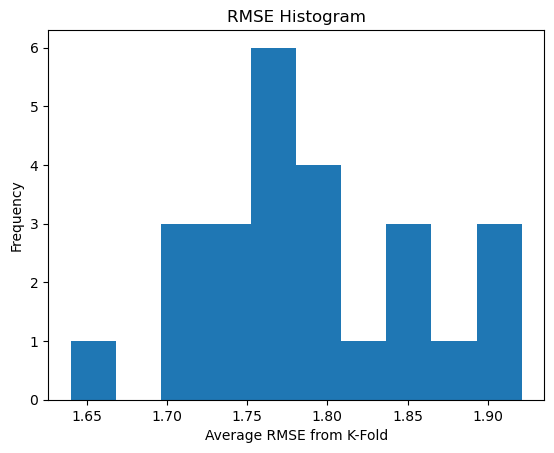

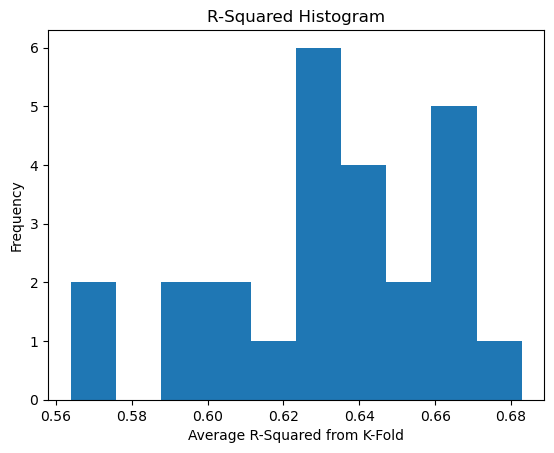

In [13]:
#train models 
#model 1
rmse_1, r2_1 = run_kfold(xtrain1, ytrain1, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain1, ytrain1, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain1, ytrain1, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain1, ytrain1, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain1, ytrain1, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

Not surprising that this particular model has similar results to the main. Sentinel 2 has a temporal frequency of about 1 week. So the structure of the model is not changing a ton here.

Test RMSE: 1.7060988
Test R2: 0.6319683194160461


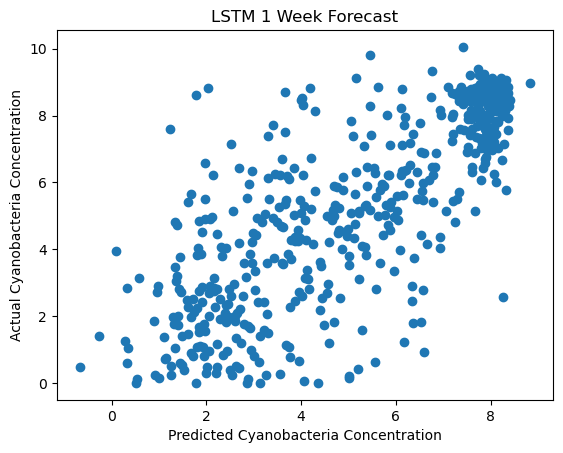

In [14]:
#train final model and run on the test set 
xtest1, _ = scale_data(xtest1, scaler=scaler, fit=False)
preds, y_true, model, rmse, r2 = run_model_no_kfold(
    xtrain1, ytrain1,
    xtest1, ytest1,
    input_size=xtrain1.shape[2],
    hidden_size=32,
    num_layers=1,
    learning_rate=0.01,
    loss_type="mse"
)

print("Test RMSE:", rmse)
preds = preds.numpy()
y_true = y_true.numpy()
r2 = r2_score(y_true, preds)
print("Test R2:", r2)

plt.scatter(preds, y_true)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.title("LSTM 1 Week Forecast")
plt.show()

#### 2 Weeks Forecasting Model

In [15]:
df2 = pd.read_csv('week2_ww_7.csv')
print(df2.shape)

(40985, 23)


In [21]:
df2.head(21)

,system:index,NIR,SWIR,blue,cloud_score,cyanobacteria_abundance,green,latitude,longitude,ndci,...,red,red_edge,sample_date,satellite_date,.geo,mean_diff_days,std_diff_days,precip_3d_mm,wind_speed_ms,solar_rad_wm2
35430,233_20170620T160509_20170620T160511_T17RNK,0.092608,0.039259,0.078572,0.688545,572.831970,0.078790,26.944528,-80.832907,-0.116373,...,0.084167,0.066620,2017-08-22,2017-06-20,"{""type"":""MultiPoint"",""coordinates"":[]}",7.500000,4.505552,27.09,4.03,6.4994
35260,233_20170623T155909_20170623T161535_T17RNK,0.486871,0.383751,0.467628,0.544522,572.831970,0.470586,26.944528,-80.832907,-0.080961,...,0.467709,0.397640,2017-08-22,2017-06-23,"{""type"":""MultiPoint"",""coordinates"":[]}",7.500000,4.505552,4.08,3.18,7.1558
35099,233_20170625T160511_20170625T160509_T17RNK,0.036484,0.003188,0.025695,0.381487,572.831970,0.030088,26.944528,-80.832907,-0.386147,...,0.030737,0.013608,2017-08-22,2017-06-25,"{""type"":""MultiPoint"",""coordinates"":[]}",7.500000,4.505552,3.97,2.15,6.6665
34715,233_20170703T155909_20170703T161513_T17RNK,0.241544,0.156122,0.278963,0.456271,572.831970,0.225625,26.944528,-80.832907,-0.305852,...,0.234832,0.117237,2017-08-22,2017-07-03,"{""type"":""MultiPoint"",""coordinates"":[]}",7.500000,4.505552,13.75,2.06,6.6103
34170,233_20170715T160511_20170715T160512_T17RNK,0.027385,0.003710,0.009762,0.329016,572.831970,0.016350,26.944528,-80.832907,-0.999723,...,0.021415,0.000003,2017-08-22,2017-07-15,"{""type"":""MultiPoint"",""coordinates"":[]}",7.500000,4.505552,32.36,2.30,6.5258
33720,233_20170728T155901_20170728T161200_T17RNK,0.259945,0.215593,0.238309,0.298679,572.831970,0.249222,26.944528,-80.832907,-0.065100,...,0.248364,0.217955,2017-08-22,2017-07-28,"{""type"":""MultiPoint"",""coordinates"":[]}",7.500000,4.505552,7.09,1.81,6.7015
33437,233_20170804T160511_20170804T160513_T17RNK,0.052315,0.021834,0.035691,0.148106,572.831970,0.044746,26.944528,-80.832907,-0.201238,...,0.045581,0.030308,2017-08-22,2017-08-04,"{""type"":""MultiPoint"",""coordinates"":[]}",7.500000,4.505552,21.45,2.28,6.6552
33592,2370_20170730T165451_20170730T165453_T15RWP,0.074721,0.005205,0.066291,0.071138,17.292000,0.081234,29.891629,-92.754510,-0.537626,...,0.074571,0.022425,2017-09-14,2017-07-30,"{""type"":""MultiPoint"",""coordinates"":[]}",4.166667,3.060501,4.75,3.04,7.1530
33417,2370_20170804T165449_20170804T165451_T15RWP,0.151642,0.130575,0.103156,0.620631,17.292000,0.118465,29.891629,-92.754510,-0.001587,...,0.132444,0.132275,2017-09-14,2017-08-04,"{""type"":""MultiPoint"",""coordinates"":[]}",4.166667,3.060501,27.41,1.25,4.6303
33053,2370_20170814T163859_20170814T165227_T15RWP,0.146437,0.115187,0.140397,0.391295,17.292000,0.140058,29.891629,-92.754510,-0.099778,...,0.132868,0.108670,2017-09-14,2017-08-14,"{""type"":""MultiPoint"",""coordinates"":[]}",4.166667,3.060501,28.76,2.95,6.9773


In [16]:
#sort
df2 = df2.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [23]:
#prep data format for LSTM model
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge',
                'cloud_score', 'mean_diff_days', 'std_diff_days',
               'precip_3d_mm', 'wind_speed_ms', 'solar_rad_wm2']
xdata2 = []
ydata2 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df2.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 7
    if len(group) == 7:
        seq = group[feature_cols].values

        #input features
        xdata2.append(seq)

        #target feature
        ydata2.append(group['cyanobacteria_abundance'].iloc[0])

xdata2 = np.array(xdata2)
ydata2 = np.array(ydata2)

#take log of cyanobacteria abundance
ydata2 = np.log1p(ydata2)

print("Shape of Data for 2 Week Forecast")
print(xdata2.shape)

Shape of Data for 2 Week Forecast
(5855, 7, 16)


In [18]:
#train test split
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(xdata2, ydata2, test_size = 0.1, random_state = 999)
xtrain2, scaler = scale_data(xtrain2, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 1.793 ± 0.038
R2: 0.629 ± 0.011

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 1.806 ± 0.050
R2: 0.624 ± 0.021

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 1.825 ± 0.043
R2: 0.616 ± 0.011

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 1.886 ± 0.065
R2: 0.590 ± 0.022

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 1.866 ± 0.088
R2: 0.597 ± 0.038



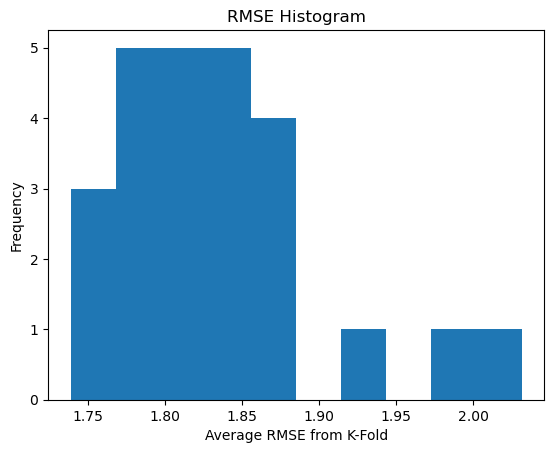

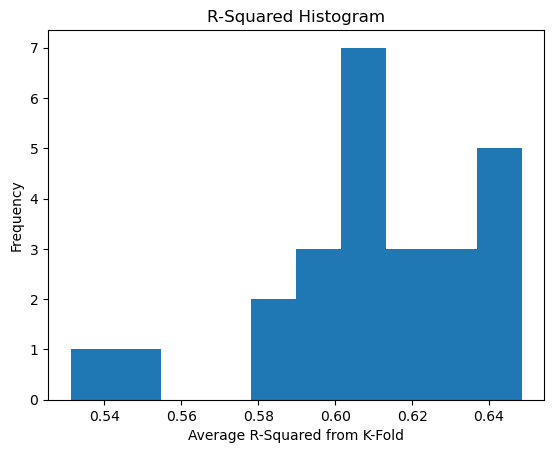

In [19]:
#train models 
#model 1
rmse_1, r2_1 = run_kfold(xtrain2, ytrain2, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain2, ytrain2, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain2, ytrain2, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain2, ytrain2, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain2, ytrain2, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()